# 基本面因子

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## 数据处理基础函数

In [2]:
def to_quarterly(data):
    """Convert cumulative financial data to quarterly data"""
    rslt = {}
    data = data.sort_index()
    data = data.loc[[x % 10000 in [331, 630, 930, 1231] for x in data.index]]
    
    for i in range(len(data)):
        date = data.index[i]
        if int(date) % 10000 == 331:  # Q1 is already quarterly
            quarter_data = data.iloc[i]
        else:
            if i >= 1:  # Subtract previous cumulative to get quarterly
                quarter_data = data.iloc[i] - data.iloc[i - 1]  
            else:  # First occurrence, estimate quarterly
                if int(date) % 10000 == 630:
                    quarter_data = data.iloc[i] / 2
                elif int(date) % 10000 == 930:
                    quarter_data = data.iloc[i] / 3 
                elif int(date) % 10000 == 1231:
                    quarter_data = data.iloc[i] / 4
            
        rslt[date] = quarter_data
    return pd.DataFrame(rslt).T.sort_index()

In [3]:
def _deal_ann_date(anndt_bs, trade_days, stocks):
    """Map trading days to the most recent announced financial report date"""
    matric_anndate_bs = {}
    for keyday in trade_days:
        matric_anndate_bs[keyday] = {}
        for ticker in stocks:
            try:
                bs = anndt_bs[ticker]
            except:
                continue

            report_date = -1
            for k, ann_dt in bs.items():
                if not np.isnan(ann_dt):
                    if ann_dt >= keyday:  # Future data, break
                        break
                    else:
                        report_date = int(k)

            matric_anndate_bs[keyday][ticker] = report_date
    return pd.DataFrame(matric_anndate_bs).T

In [4]:
def _date_adjust(df, matric_anndate):
    """Adjust financial data timestamps to announcement dates"""
    data = {}
    for c in df.columns:
        try:
            xd = matric_anndate[c]
            xd = xd.loc[xd > 0]
        except:
            continue
        v = df.loc[xd.values, c].values
        t = list(xd.index)
        data[c] = pd.Series(v, index=t)
    return pd.DataFrame(data)

In [5]:
def top_n_fill(df, n):
    """Create binary weights for top n stocks"""
    result_df = pd.DataFrame(0, index=df.index, columns=df.columns)
    for index, row in df.iterrows():
        top_indices = row.nlargest(n).index
        result_df.loc[index, top_indices] = 1
    return result_df

## 数据加载和预处理函数

In [6]:
def load_base_data():
    """Load market data and announcement dates
    
    Returns:
        tuple: (market_value, announcement_date, matric_anndate, adj_close, price_ret)
    """
    print("Loading base data...")
    market_value = pd.read_csv("data/market_cap.csv", index_col=0)
    announcement_date = pd.read_csv("data/announcement_date.csv", index_col=0)
    
    # Create announcement date mapping
    stocks = market_value.columns
    trade_days = market_value.index
    matric_anndate = _deal_ann_date(announcement_date, trade_days, stocks)
    
    # Load and prepare price data
    adj_close = pd.read_csv('data/adjclose.csv', index_col=0)
    ts = market_value.index
    adj_close = adj_close.loc[ts].ffill()
    price_ret = adj_close.shift(-1) / adj_close - 1
    
    print(f"Base data loaded: {market_value.shape[0]} days, {market_value.shape[1]} stocks")
    
    return market_value, announcement_date, matric_anndate, adj_close, price_ret

In [7]:
def process_financial_data(data_path, matric_anndate, use_ttm=True):
    """Process financial statement data with quarterly conversion and TTM calculation
    
    NOTE: This function should ONLY be used for cumulative financial data like net_profit
    that needs quarterly conversion and TTM calculation.
    
    Args:
        data_path: Path to the financial data CSV file
        matric_anndate: Announcement date mapping matrix
        use_ttm: Whether to calculate TTM (trailing twelve months)
    
    Returns:
        DataFrame: Processed financial data aligned to trading dates
    """
    print(f"Processing cumulative financial data: {data_path}")
    
    # Load raw data
    data = pd.read_csv(data_path, index_col=0)
    
    # Convert to quarterly
    data_quarter = to_quarterly(data)
    
    # Calculate TTM if requested
    if use_ttm:
        data_quarter_ttm = data_quarter.rolling(4).sum()
    else:
        data_quarter_ttm = data_quarter
        
    # Adjust to trading dates
    data_trade_date = _date_adjust(data_quarter_ttm, matric_anndate)
    
    return data_trade_date

In [8]:
def process_balance_sheet_data(data_path, matric_anndate):
    """Process balance sheet data that doesn't need quarterly conversion
    
    This function should be used for point-in-time balance sheet data like 
    equity, total_assets, market_cap that don't need quarterly conversion or TTM calculation.
    
    Args:
        data_path: Path to the balance sheet data CSV file
        matric_anndate: Announcement date mapping matrix
    
    Returns:
        DataFrame: Balance sheet data aligned to trading dates
    """
    print(f"Processing balance sheet data: {data_path}")
    
    # Load raw data
    data = pd.read_csv(data_path, index_col=0)
    
    # Only filter to quarterly reporting dates
    data = data.sort_index()
    data = data.loc[[x % 10000 in [331, 630, 930, 1231] for x in data.index]]
    
    # Adjust to trading dates
    data_trade_date = _date_adjust(data, matric_anndate)
    
    return data_trade_date

## 因子计算和回测函数

In [9]:
def calculate_factor(factor_name, matric_anndate, n_stocks=50, 
                    numerator_path=None, denominator_path=None, 
                    numerator_data=None, denominator_data=None, 
                    ascending=True, filter_negative=True, filter_extreme=None,
                    numerator_is_cumulative=False, denominator_is_cumulative=False):
    """
    Calculate a fundamental factor
    
    Parameters:
    - factor_name: Name of the factor
    - matric_anndate: Announcement date mapping matrix
    - n_stocks: Number of top stocks to select
    - numerator_path/denominator_path: Paths to CSV files
    - numerator_data/denominator_data: Pre-loaded data
    - ascending: True for low values (like PB), False for high values (like ROE)
    - filter_negative: Remove negative values
    - filter_extreme: Tuple (min, max) to filter extreme values
    - numerator_is_cumulative: Whether numerator needs quarterly conversion and TTM
    - denominator_is_cumulative: Whether denominator needs quarterly conversion and TTM
    
    Returns:
        tuple: (factor_values, weights)
    """
    print(f"\nCalculating {factor_name} factor...")
    
    # Load numerator data
    if numerator_data is None:
        if numerator_is_cumulative:
            numerator_data = process_financial_data(numerator_path, matric_anndate)
        else:
            numerator_data = process_balance_sheet_data(numerator_path, matric_anndate)
    
    # Load denominator data
    if denominator_data is None:
        if denominator_is_cumulative:
            denominator_data = process_financial_data(denominator_path, matric_anndate)
        else:
            denominator_data = process_balance_sheet_data(denominator_path, matric_anndate)
        
    # Calculate factor
    factor = numerator_data / denominator_data
    
    # Apply filters
    if filter_negative:
        factor = factor.applymap(lambda x: np.nan if x < 0 else x)
        
    if filter_extreme:
        min_val, max_val = filter_extreme
        factor = factor.applymap(lambda x: np.nan if x < min_val or x > max_val else x)
    
    # Create weights (invert for ascending factors like PB)
    factor_for_ranking = -factor if ascending else factor
    weights = top_n_fill(factor_for_ranking, n_stocks)
    
    return factor, weights

In [10]:
def backtest_factor(factor_name, weights, price_ret, n_stocks=50):
    """Run backtest for a factor
    
    Args:
        factor_name: Name of the factor
        weights: Factor weights matrix
        price_ret: Price return matrix
        n_stocks: Number of stocks in portfolio
    
    Returns:
        dict: Backtest results containing returns and performance metrics
    """
    print(f"Backtesting {factor_name}...")
    
    # Calculate portfolio returns
    portfolio_ret = (weights * price_ret).sum(1) / n_stocks
    
    # Calculate performance metrics
    apy = portfolio_ret.mean() * 12
    vol = portfolio_ret.std() * 12 ** 0.5
    sharpe = apy / vol if vol > 0 else 0
    
    print(f"APY = {apy * 100:.1f}%, Sharpe = {sharpe:.2f}")
    
    # Return results
    result = {
        'returns': portfolio_ret,
        'apy': apy,
        'volatility': vol,
        'sharpe': sharpe,
        'weights': weights
    }
    
    return result

## 可视化和分析函数

In [11]:
def plot_cumulative_returns(results_dict, factor_names=None, n_stocks=50):
    """Plot cumulative returns for selected factors
    
    Args:
        results_dict: Dictionary of factor results
        factor_names: List of factor names to plot (None for all)
        n_stocks: Number of stocks in portfolio
    """
    if factor_names is None:
        factor_names = list(results_dict.keys())
        
    plt.figure(figsize=(12, 6))
    for name in factor_names:
        if name in results_dict:
            returns = results_dict[name]['returns']
            returns.index = [str(x) for x in returns.index]
            plt.plot(returns.cumsum(), label=f"{name} (Sharpe: {results_dict[name]['sharpe']:.2f})")
    
    plt.title(f"Cumulative Returns Comparison (Top {n_stocks} Stocks)")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [12]:
def show_performance_summary(results_dict):
    """Display performance summary table
    
    Args:
        results_dict: Dictionary of factor results
    """
    if not results_dict:
        print("No backtest results available.")
        return
        
    summary_data = []
    for name, result in results_dict.items():
        summary_data.append({
            'Factor': name,
            'APY (%)': f"{result['apy'] * 100:.1f}",
            'Volatility (%)': f"{result['volatility'] * 100:.1f}",
            'Sharpe Ratio': f"{result['sharpe']:.2f}"
        })
    
    summary_df = pd.DataFrame(summary_data)
    print("\n" + "="*50)
    print("FACTOR PERFORMANCE SUMMARY")
    print("="*50)
    display(summary_df)

## 数据初始化

In [13]:
# Load base data
market_value, announcement_date, matric_anndate, adj_close, price_ret = load_base_data()

# Configuration
N_STOCKS = 50  # Number of stocks to select for each factor

Loading base data...
Base data loaded: 168 days, 5308 stocks


## 因子测试

In [14]:
# Initialize results dictionary
factor_results = {}

# 1. PB = Market Value / Book Equity
# Both are point-in-time values, no TTM needed
pb_factor, pb_weights = calculate_factor(
    factor_name="PB",
    matric_anndate=matric_anndate,
    n_stocks=N_STOCKS,
    numerator_data=market_value,  # Already loaded, point-in-time
    denominator_path="data/equity.csv",
    denominator_is_cumulative=False,  # Balance sheet item, no TTM needed
    ascending=True,  # Lower PB is better
    filter_negative=True
)

factor_results['PB'] = backtest_factor("PB", pb_weights, price_ret, N_STOCKS)


Calculating PB factor...
Processing balance sheet data: data/equity.csv
Backtesting PB...
APY = 8.0%, Sharpe = 0.35


In [15]:
# 2. Leverage = Total Assets / Equity
# Both are balance sheet items, no TTM needed
leverage_factor, leverage_weights = calculate_factor(
    factor_name="Leverage",
    matric_anndate=matric_anndate,
    n_stocks=N_STOCKS,
    numerator_path="data/total_assets.csv",
    numerator_is_cumulative=False,  # Balance sheet item, no TTM needed
    denominator_path="data/equity.csv",
    denominator_is_cumulative=False,  # Balance sheet item, no TTM needed
    ascending=False,  # Higher leverage might indicate higher risk but potentially higher returns
    filter_negative=True,
    filter_extreme=(0, 100)  # Remove extreme leverage ratios
)

factor_results['Leverage'] = backtest_factor("Leverage", leverage_weights, price_ret, N_STOCKS)


Calculating Leverage factor...
Processing balance sheet data: data/total_assets.csv
Processing balance sheet data: data/equity.csv
Backtesting Leverage...
APY = 8.0%, Sharpe = 0.47


In [16]:
# 3. ROE = Net Profit / Equity
# Net profit needs TTM, equity doesn't
roe_factor, roe_weights = calculate_factor(
    factor_name="ROE",
    matric_anndate=matric_anndate,
    n_stocks=N_STOCKS,
    numerator_path="data/net_profit.csv",
    numerator_is_cumulative=True,  # Income statement item, needs TTM
    denominator_path="data/equity.csv",
    denominator_is_cumulative=False,  # Balance sheet item, no TTM needed
    ascending=False,  # Higher ROE is better
    filter_negative=True
)

factor_results['ROE'] = backtest_factor("ROE", roe_weights, price_ret, N_STOCKS)


Calculating ROE factor...
Processing cumulative financial data: data/net_profit.csv
Processing balance sheet data: data/equity.csv
Backtesting ROE...
APY = 11.1%, Sharpe = 0.43


In [17]:
# 4. ROA = Net Profit / Total Assets
# Net profit needs TTM, total assets doesn't
roa_factor, roa_weights = calculate_factor(
    factor_name="ROA",
    matric_anndate=matric_anndate,
    n_stocks=N_STOCKS,
    numerator_path="data/net_profit.csv",
    numerator_is_cumulative=True,  # Income statement item, needs TTM
    denominator_path="data/total_assets.csv",
    denominator_is_cumulative=False,  # Balance sheet item, no TTM needed
    ascending=False,  # Higher ROA is better
    filter_negative=True
)

factor_results['ROA'] = backtest_factor("ROA", roa_weights, price_ret, N_STOCKS)


Calculating ROA factor...
Processing cumulative financial data: data/net_profit.csv
Processing balance sheet data: data/total_assets.csv
Backtesting ROA...
APY = 10.0%, Sharpe = 0.36


In [18]:
# 5. YOY = (net profit - net profit lag) / net profit lag
# This one is special - it needs the TTM net profit data
net_profit_ttm = process_financial_data("data/net_profit.csv", matric_anndate, use_ttm=True)
net_profit_ttm_lag = net_profit_ttm.shift(4)
yoy = (net_profit_ttm - net_profit_ttm_lag) / net_profit_ttm_lag
yoy = yoy.applymap(lambda x: np.nan if x < 0 else x)
yoy_weights = top_n_fill(yoy, N_STOCKS)

factor_results['YOY'] = backtest_factor("YOY", yoy_weights, price_ret, N_STOCKS)

Processing cumulative financial data: data/net_profit.csv
Backtesting YOY...
APY = 15.7%, Sharpe = 0.55


## 因子对比


FACTOR PERFORMANCE SUMMARY


,Factor,APY (%),Volatility (%),Sharpe Ratio
0,PB,8.0,23.1,0.35
1,Leverage,8.0,17.2,0.47
2,ROE,11.1,25.7,0.43
3,ROA,10.0,28.2,0.36
4,YOY,15.7,28.4,0.55


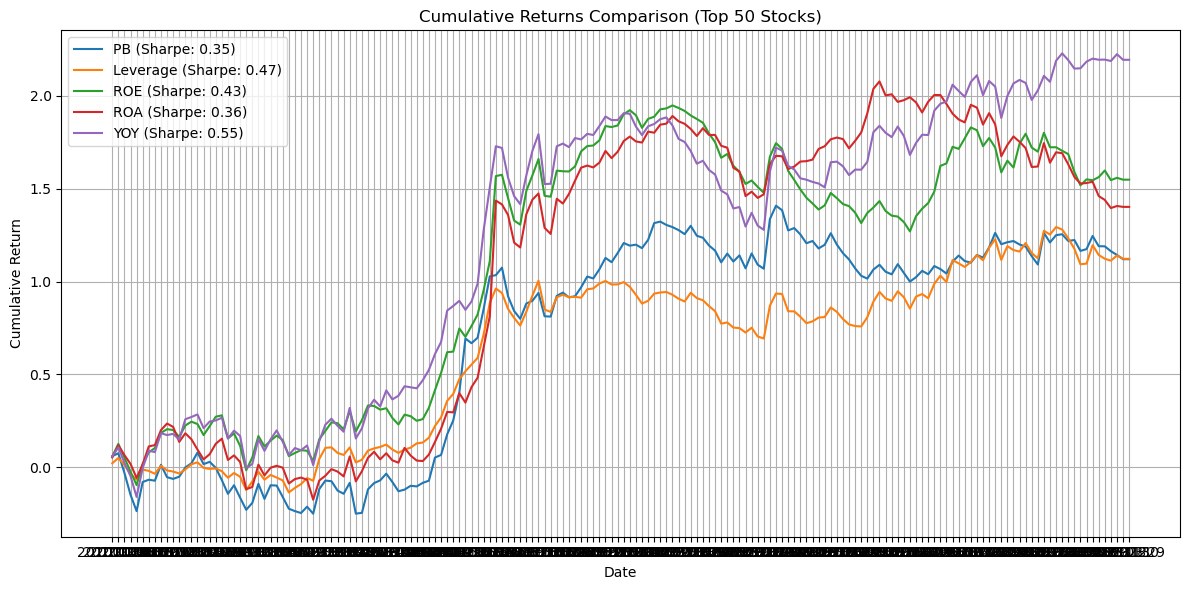

In [19]:
# Display performance summary
show_performance_summary(factor_results)

# Plot cumulative returns comparison
plot_cumulative_returns(factor_results, n_stocks=N_STOCKS)

**需要TTM处理**：`net_profit`（损益表科目，累计数据）
**不需要TTM处理**：`equity`, `total_assets`, `market_cap`（资产负债表科目，时点数据）
   - PB：market_value（时点） / equity（时点，不需要TTM）
   - Leverage：total_assets（时点，不需要TTM） / equity（时点，不需要TTM）
   - ROE：net_profit（累计，需要TTM） / equity（时点，不需要TTM）
   - ROA：net_profit（累计，需要TTM） / total_assets（时点，不需要TTM）

In [20]:
# Create a factors dictionary similar to volume_and_price approach
factors = {}

# Extract factor values from the calculation results
factors['PB'] = pb_factor
factors['Leverage'] = leverage_factor  
factors['ROE'] = roe_factor
factors['ROA'] = roa_factor
factors['YOY'] = yoy  # This was calculated directly

# Now you can combine with volume_and_price factors
# Assuming you have the volume_and_price factors in a dict called 'volume_price_factors'
# all_factors = {**volume_price_factors, **factors}

In [22]:
for factor_name, factor_data in factors.items():
    print(f"\n=== {factor_name} Statistics ===")
    print(factor_data.head())


=== PB Statistics ===
          000001.SZ  000002.SZ  000004.SZ  000005.SZ  000006.SZ  000007.SZ  \
20100129   3.530301   2.938957  14.217875   6.657675   2.679652        NaN   
20100226   3.652316   2.967277  14.729719   6.904713   2.792649        NaN   
20100331   3.519660   2.794703  16.179942   7.361734   2.880831        NaN   
20100430   2.887753   2.200216  14.242192   5.916561   2.256139        NaN   
20100531   2.459366   2.033789  12.372560   5.731063   1.940943        NaN   

          000008.SZ  000009.SZ  000010.SZ  000011.SZ  ...  688787.SH  \
20100129   9.601271   6.007813  36.647383   7.934809  ...        NaN   
20100226  11.066886   6.514705  40.081070   9.001282  ...        NaN   
20100331  13.098149   6.449037  44.284929  10.587094  ...        NaN   
20100430  12.365032   6.074787  47.157512   7.427104  ...        NaN   
20100531  13.832752   4.726052  47.157512   6.377622  ...        NaN   

          688788.SH  688789.SH  688793.SH  688798.SH  688799.SH  688800.SH 

In [48]:
# In fundamental.ipynb - Add this cell after creating the factors dictionary
import pickle
import os

# Save fundamental factors
with open('fundamental_factors.pkl', 'wb') as f:
    pickle.dump(factors, f)

print(f"Saved fundamental factors: {list(factors.keys())}")

Saved fundamental factors: ['PB', 'Leverage', 'ROE', 'ROA', 'YOY']
